In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Leer datos
df = pd.read_csv("main/data/interim/datos_limpios.csv", parse_dates=["date"])
df = df.sort_values("date")

# Variables numéricas
features = ["CO","NO","NO2","NOX","O3","PM10","PM2.5","PRS","RAINF","RH","SO2","SR","TOUT","WSR","WDR"]

# Asegurar columna 'Estacion' (usar 'Zona' si no existe)
if 'Estacion' not in df.columns and 'Zona' in df.columns:
    df['Estacion'] = df['Zona']

estaciones = ['CENTRO', 'NORTE', 'SURESTE']
# Filtrar solo las estaciones deseadas para evitar columnas extra
df = df[df['Estacion'].isin(estaciones)]

# --- FIX: Pivotar PRIMERO para tener índice único por fecha ---
df_wide = df.pivot_table(index='date', columns='Estacion', values=features, aggfunc='mean')

# Flatten columnas MultiIndex -> "feature_ESTACION"
df_wide.columns = [f"{feat}_{est}" for feat, est in df_wide.columns]

# --- FIX: Asegurar frecuencia horaria completa ---
df_wide = df_wide.reindex(pd.date_range(start=df_wide.index.min(), end=df_wide.index.max(), freq='h'))

# Actualizar lista de features
features_wide = df_wide.columns.tolist()

# Escalar variables
df_wide[features_wide] = (df_wide[features_wide] - df_wide[features_wide].mean()) / df_wide[features_wide].std()

# Agrupar por semana
X_list = []
timestamps_list = [] # Nuevo: guardar índices de las filas usadas
for _, group in df_wide.groupby(pd.Grouper(freq="W")):
    if len(group) == 168:  # solo semanas completas
        data = group[features_wide].values
        X_list.append(data)
        timestamps_list.append(group.index) # Guardar fechas

print(f"Generadas {len(X_list)} secuencias de semanas completas.")

# Convertir a tensor 3D
if len(X_list) > 0:
    X = np.stack(X_list, axis=0)   # shape (n_samples, 168, n_features)
    timestamps = np.concatenate(timestamps_list) # Unir todos los índices en un solo array
    print("Shape final:", X.shape)
else:
    print("Error: No se generaron secuencias.")

Generadas 286 secuencias de semanas completas.
Shape final: (286, 168, 45)


In [28]:
from pypots.imputation import SAITS

model = SAITS(
    n_steps=168,              # horas por semana
    n_features=X.shape[2],    # número de variables
    n_layers=2,
    d_model=256,
    n_heads=8,
    d_k=16,
    d_v=16,
    d_ffn=512,
    dropout=0.1,
    epochs=300,
    batch_size=32,
)

# PyPOTS requiere un diccionario con la clave "X"
dataset = {"X": X}

model.fit(dataset)
X_imputed = model.impute

2025-12-03 20:30:34 [INFO]: No given device, using default device: cuda
2025-12-03 20:30:34 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-12-03 20:30:34 [INFO]: Using customized MAE as the training loss function.
2025-12-03 20:30:34 [INFO]: Using customized MSE as the validation metric function.
2025-12-03 20:30:34 [WARNING]: ‼️ d_model must = n_heads * d_k, it should be divisible by n_heads and the result should be equal to d_k, but got d_model=256, n_heads=8, d_k=16
2025-12-03 20:30:34 [WARNING]: ⚠️ d_model is reset to 128 = n_heads (8) * d_k (16)
2025-12-03 20:30:34 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 837,646
2025-12-03 20:30:35 [INFO]: Epoch 001 - training loss (MAE): 1.2730
2025-12-03 20:30:35 [INFO]: Epoch 002 - training loss (MAE): 1.0605
2025-12-03 20:30:36 [INFO]: Epoch 003 - training loss (MAE): 0.9406
2025-12-03 20:30:36 [INFO]: Epoch 004 - training loss (MAE): 0.8690
20

Comparison: Original vs Imputed Data
               MSE  MAE  RMSE  n_samples
CO_CENTRO      0.0  0.0   0.0    46616.0
CO_NORTE       0.0  0.0   0.0    34530.0
CO_SURESTE     0.0  0.0   0.0    43488.0
NO_CENTRO      0.0  0.0   0.0    42969.0
NO_NORTE       0.0  0.0   0.0    34319.0
NO_SURESTE     0.0  0.0   0.0    35631.0
NO2_CENTRO     0.0  0.0   0.0    45035.0
NO2_NORTE      0.0  0.0   0.0    34525.0
NO2_SURESTE    0.0  0.0   0.0    36865.0
NOX_CENTRO     0.0  0.0   0.0    45238.0
NOX_NORTE      0.0  0.0   0.0    34684.0
NOX_SURESTE    0.0  0.0   0.0    36868.0
O3_CENTRO      0.0  0.0   0.0    44361.0
O3_NORTE       0.0  0.0   0.0    36070.0
O3_SURESTE     0.0  0.0   0.0    46054.0
PM10_CENTRO    0.0  0.0   0.0    46652.0
PM10_NORTE     0.0  0.0   0.0    43772.0
PM10_SURESTE   0.0  0.0   0.0    46280.0
PM2.5_CENTRO   0.0  0.0   0.0    41196.0
PM2.5_NORTE    0.0  0.0   0.0    33229.0
PM2.5_SURESTE  0.0  0.0   0.0    41736.0
PRS_CENTRO     0.0  0.0   0.0    47137.0
PRS_NORTE      0.0  

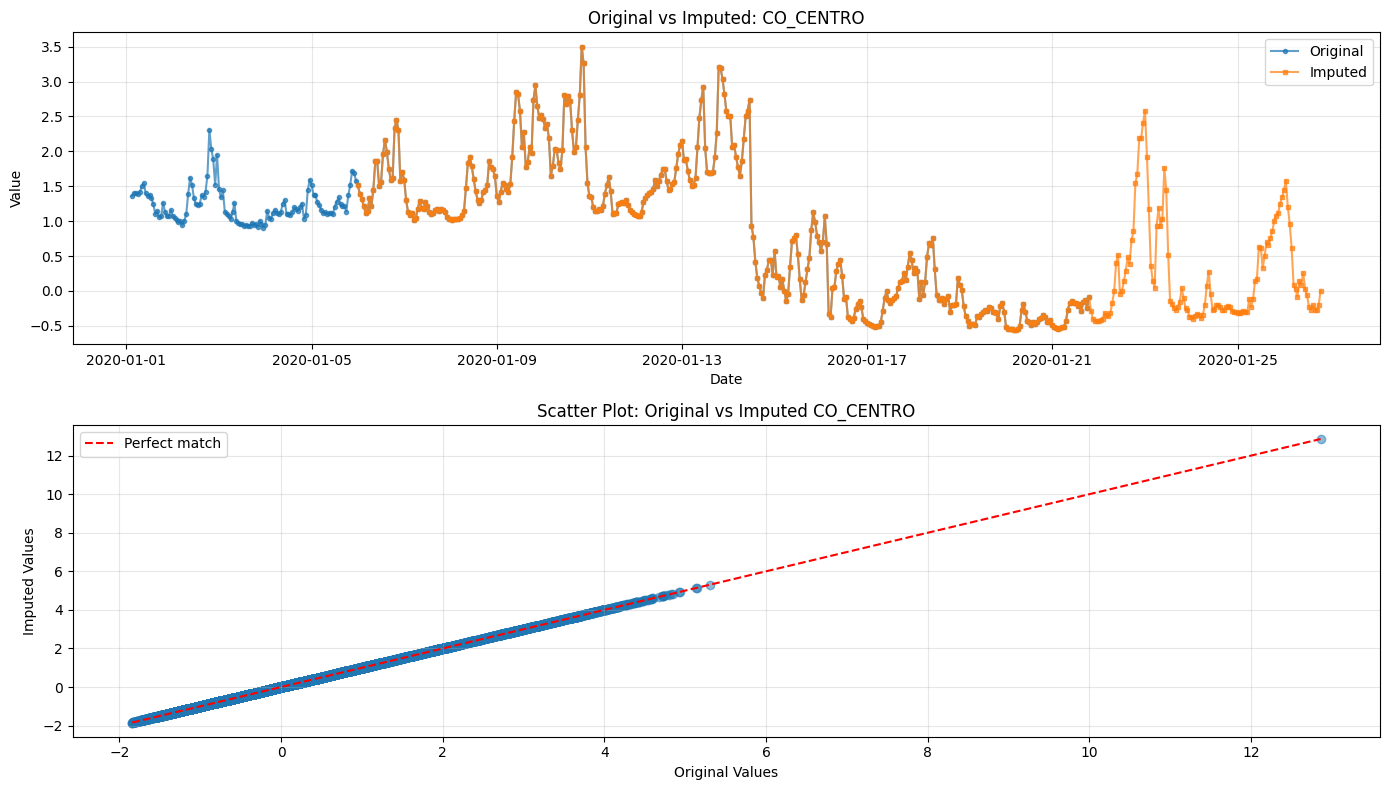

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Get imputed data
X_imputed = model.impute(dataset)

# Reshape imputed data back to wide format
X_imputed_2d = X_imputed.reshape(-1, X_imputed.shape[2])
df_imputed = pd.DataFrame(X_imputed_2d, columns=features_wide)

# --- FIX: Asignar el índice correcto recuperado de la etapa de preparación ---
df_imputed.index = timestamps 

comparison_results = {}

for col in features_wide:
    # Alinear df_wide y df_imputed por índice (intersección)
    # Esto maneja el caso donde df_imputed es un subconjunto de df_wide (por semanas incompletas eliminadas)
    common_index = df_wide.index.intersection(df_imputed.index)
    
    # Filtrar ambos dataframes al índice común
    df_wide_subset = df_wide.loc[common_index]
    df_imputed_subset = df_imputed.loc[common_index]
    
    # Crear máscara de valores originales no nulos (sobre el subconjunto)
    mask_original = df_wide_subset[col].notna()
    
    if mask_original.sum() > 0:
        original_values = df_wide_subset.loc[mask_original, col].values
        imputed_values = df_imputed_subset.loc[mask_original, col].values
        
        # Calculate metrics
        mse = mean_squared_error(original_values, imputed_values)
        mae = mean_absolute_error(original_values, imputed_values)
        rmse = np.sqrt(mse)
        
        comparison_results[col] = {
            'MSE': mse,
            'MAE': mae,
            'RMSE': rmse,
            'n_samples': len(original_values)
        }

comparison_df = pd.DataFrame(comparison_results).T
print("Comparison: Original vs Imputed Data")
print(comparison_df.round(6))
print(f"\nMean RMSE: {comparison_df['RMSE'].mean():.6f}")
print(f"Mean MAE: {comparison_df['MAE'].mean():.6f}")

# Visualize comparison for a sample feature
sample_feature = 'CO_CENTRO'
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Time series comparison
axes[0].plot(df_wide.index[:500], df_wide[sample_feature][:500], label='Original', alpha=0.7, marker='o', markersize=3)
axes[0].plot(df_imputed.index[:500], df_imputed[sample_feature][:500], label='Imputed', alpha=0.7, marker='s', markersize=3)
axes[0].set_title(f'Original vs Imputed: {sample_feature}')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter plot comparison (for non-null original values aligned)
# Usamos el subset alineado para el scatter plot
common_index = df_wide.index.intersection(df_imputed.index)
df_wide_subset = df_wide.loc[common_index]
df_imputed_subset = df_imputed.loc[common_index]
mask = df_wide_subset[sample_feature].notna()

axes[1].scatter(df_wide_subset.loc[mask, sample_feature], df_imputed_subset.loc[mask, sample_feature], alpha=0.5)
axes[1].plot([df_wide_subset[sample_feature].min(), df_wide_subset[sample_feature].max()], 
             [df_wide_subset[sample_feature].min(), df_wide_subset[sample_feature].max()], 
             'r--', label='Perfect match')
axes[1].set_xlabel('Original Values')
axes[1].set_ylabel('Imputed Values')
axes[1].set_title(f'Scatter Plot: Original vs Imputed {sample_feature}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

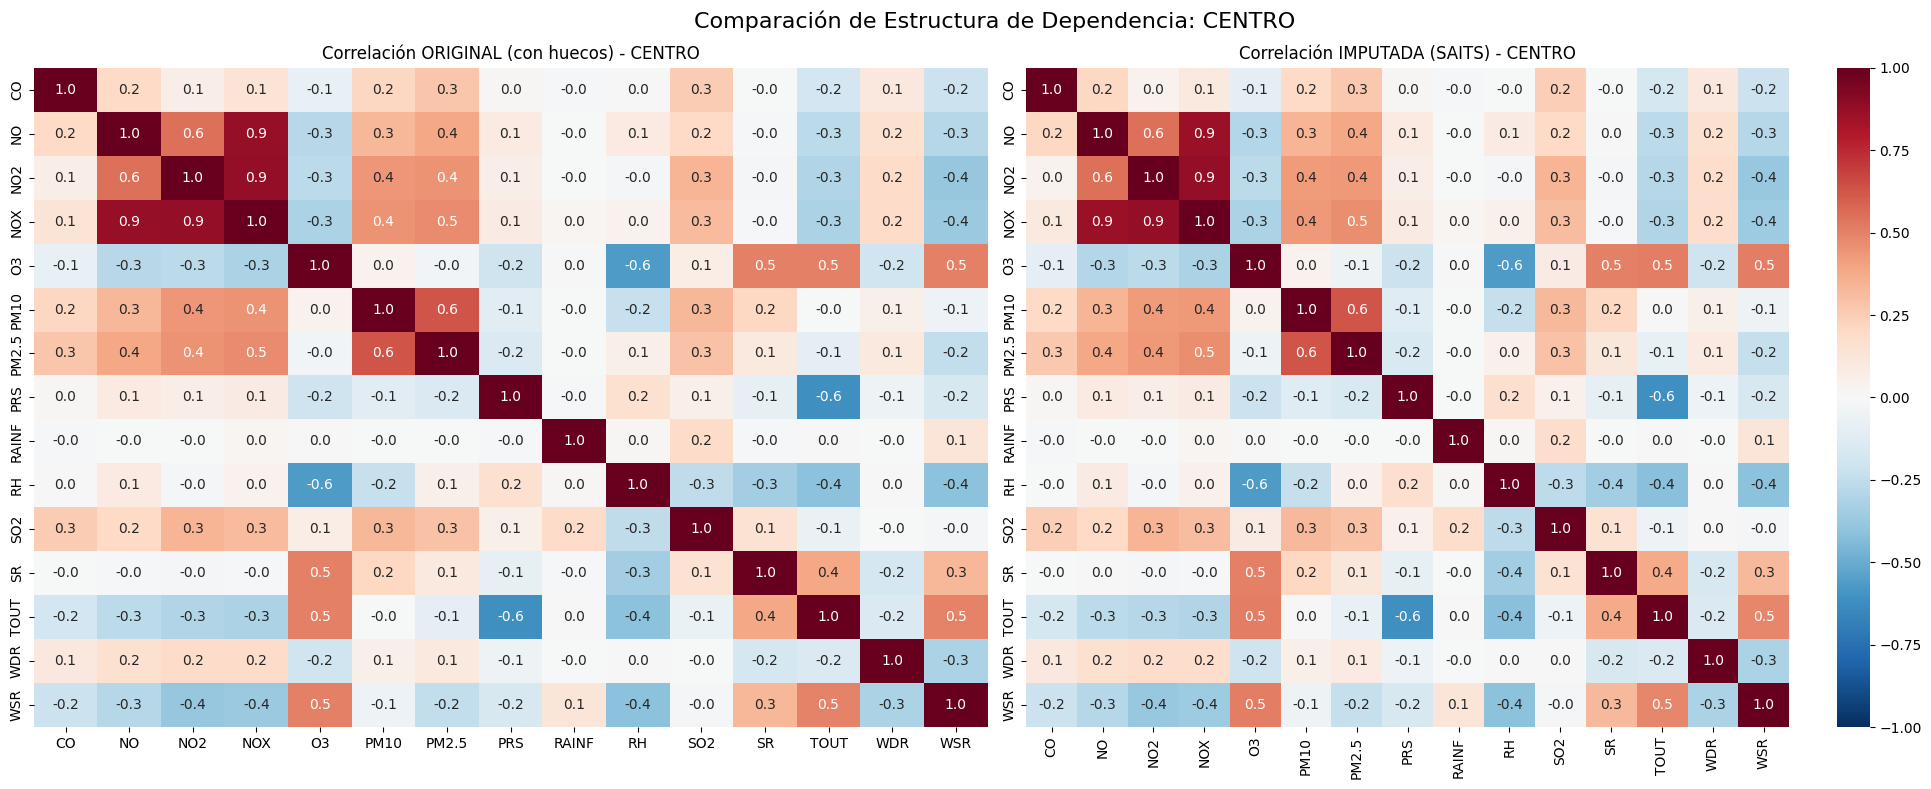

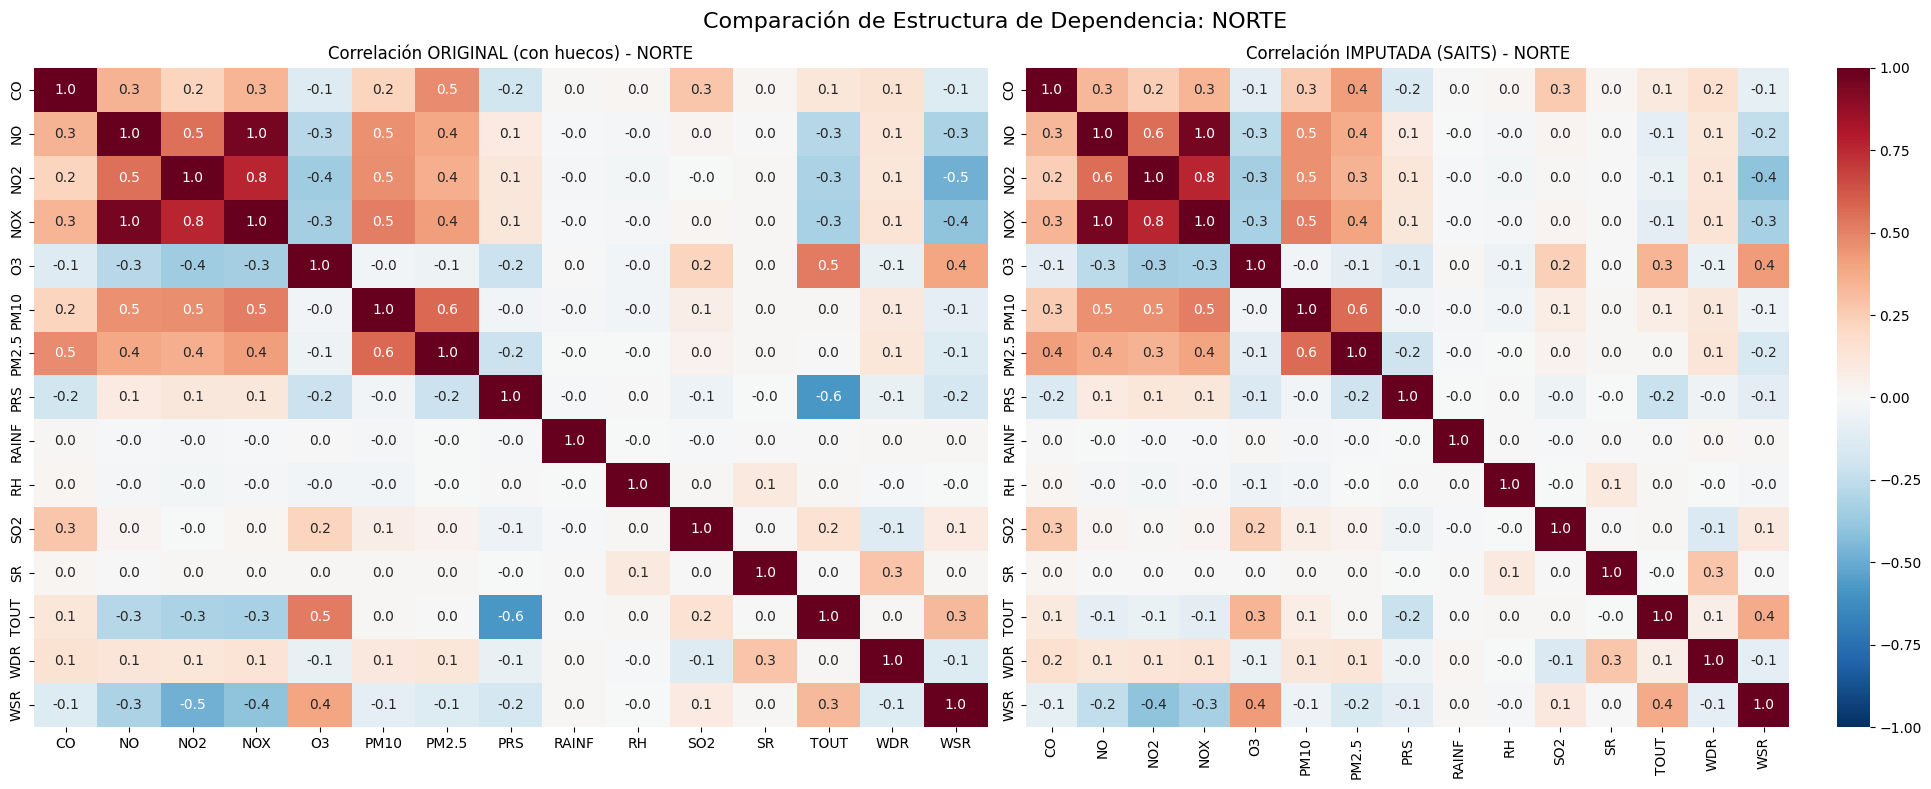

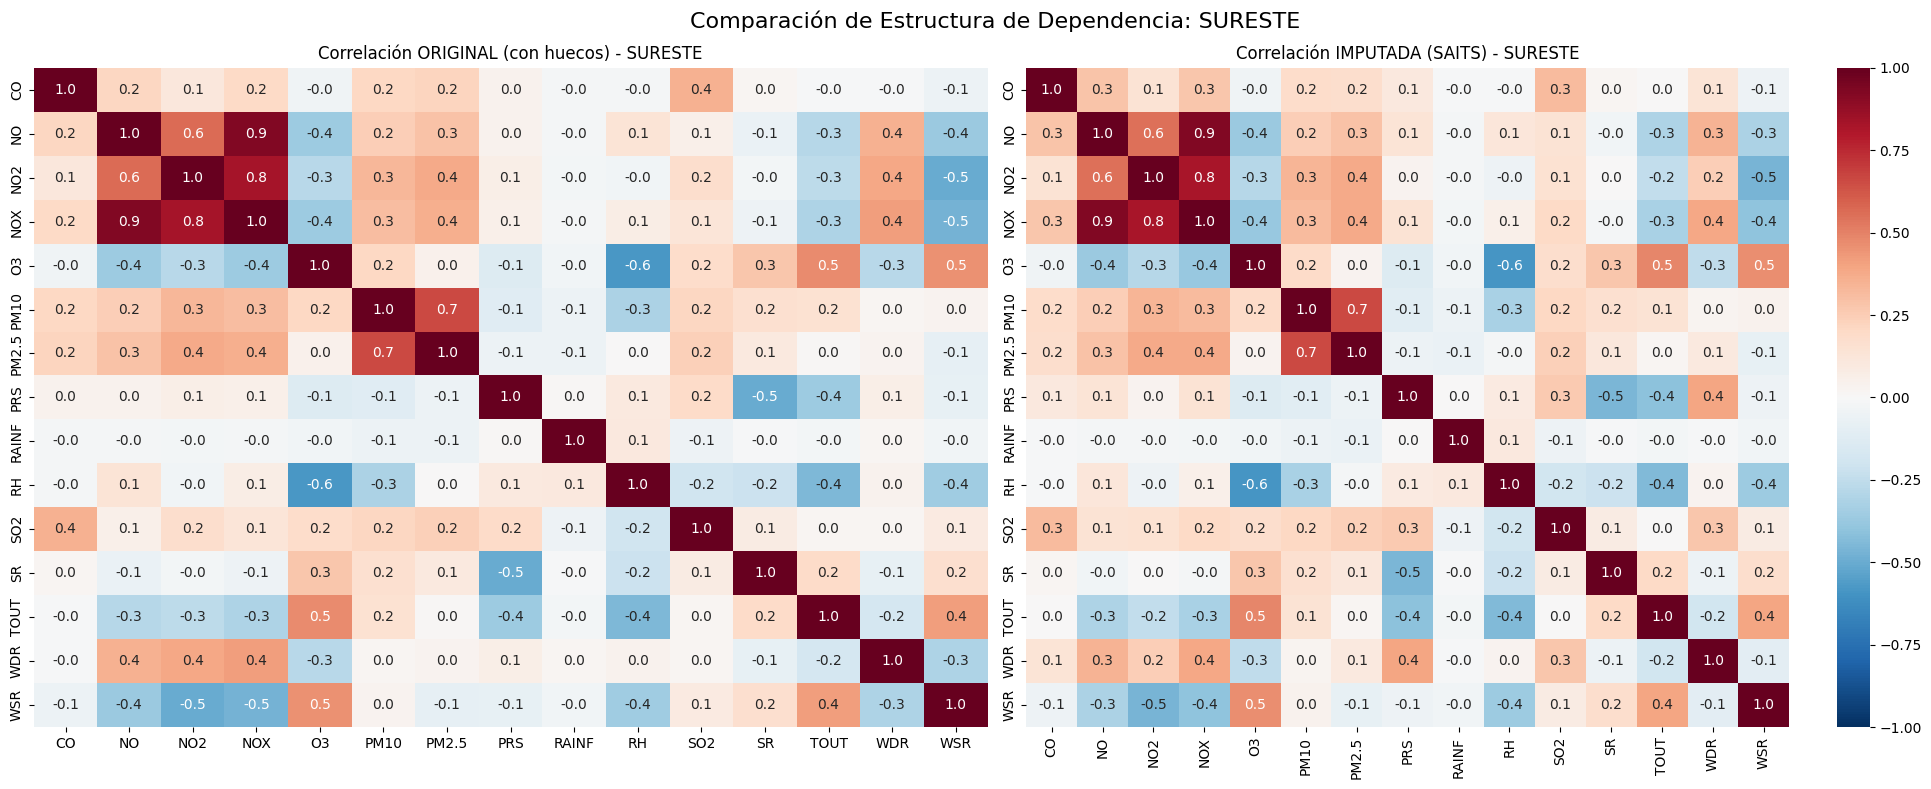

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aseguramos que los datos estén alineados temporalmente
common_index = df_wide.index.intersection(df_imputed.index)
df_orig_sub = df_wide.loc[common_index]
df_imp_sub = df_imputed.loc[common_index]

estaciones = ['CENTRO', 'NORTE', 'SURESTE']

for est in estaciones:
    # Identificar columnas de la estación actual
    cols = [c for c in df_wide.columns if c.endswith(f"_{est}")]
    
    # Calcular matrices de correlación (Pearson)
    corr_orig = df_orig_sub[cols].corr()
    corr_imp = df_imp_sub[cols].corr()
    
    # Simplificar nombres para el gráfico (quitar el sufijo _ESTACION)
    labels = [c.replace(f"_{est}", "") for c in cols]
    
    # Graficar lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Matriz Original
    sns.heatmap(corr_orig, ax=axes[0], cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt=".1f", 
                xticklabels=labels, yticklabels=labels, cbar=False)
    axes[0].set_title(f'Correlación ORIGINAL (con huecos) - {est}')
    
    # Matriz Imputada
    sns.heatmap(corr_imp, ax=axes[1], cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt=".1f",
                xticklabels=labels, yticklabels=labels)
    axes[1].set_title(f'Correlación IMPUTADA (SAITS) - {est}')
    
    plt.suptitle(f'Comparación de Estructura de Dependencia: {est}',fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Asegurar que el índice es DatetimeIndex para poder filtrar por fecha
df_imputed.index = pd.to_datetime(df_imputed.index)

target_month = '2024-08'
contaminantes = ['PM2.5', 'CO', 'NO']
estaciones = ['CENTRO', 'NORTE', 'SURESTE']

try:
    # Filtrar datos para el mes objetivo
    df_plot = df_imputed.loc[target_month]
    
    if df_plot.empty:
        print(f"No se encontraron datos imputados para {target_month}. (Es posible que las semanas de este mes estuvieran incompletas y se filtraran antes del modelo)")
    else:
        for est in estaciones:
            fig, ax = plt.subplots(figsize=(15, 5))
            
            for cont in contaminantes:
                col_name = f"{cont}_{est}"
                if col_name in df_plot.columns:
                    ax.plot(df_plot.index, df_plot[col_name], label=cont, alpha=0.8, linewidth=1.5)
            
            ax.set_title(f'Contaminantes en {est} - {target_month} (Datos Imputados)', fontsize=14)
            ax.set_xlabel('Fecha')
            ax.set_ylabel('Valor Estandarizado (Z-Score)')
            ax.legend(loc='upper right')
            ax.grid(True, alpha=0.3)
            plt.show()

except KeyError:
    print(f"El rango {target_month} no se encuentra en el índice del dataframe.")
except Exception as e:
    print(f"Ocurrió un error al graficar: {e}")